# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [1]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

descargado: taller1_datos.h5
descargado: verificacion.py
Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [2]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

>En Python, ayúdame a revisar qué contiene un archivo HDF5 usando h5py antes de trabajar con la señal. El archivo está en la variable ARCHIVO.

>Quiero abrirlo de forma segura con with y recorrer su contenido para ver qué grupos y datasets tiene. También quiero que se muestren los atributos del archivo y los atributos de los grupos, junto con el tamaño y tipo de los datasets.

>Después quiero revisar específicamente el grupo estimulos para saber cuántos ensayos hay y cuántas condiciones diferentes de estímulo se presentaron. Usa el dataset condicion para calcular esto.

>También necesito obtener de los atributos de estimulos la duración antes del estímulo, la duración del estímulo y la duración después del estímulo, y con esos datos calcular cuánto dura un ensayo completo. Hazlo con código usando h5py

In [3]:
# Su código aquí.
with h5py.File(ARCHIVO, "r") as f:

    # ============================================================
    # 1. ATRIBUTOS DEL ARCHIVO
    # ============================================================
    print("=== ATRIBUTOS DEL ARCHIVO ===")

    if len(f.attrs) == 0:
        print("El archivo no tiene atributos.")
    else:
        for nombre, valor in f.attrs.items():
            print(f"{nombre}: {valor}")

    # ============================================================
    # 2. RECORRER TODO EL CONTENIDO DEL ARCHIVO
    #    mostrando grupos, datasets y atributos
    # ============================================================
    print("\n=== CONTENIDO DEL ARCHIVO ===")

    def mostrar_contenido(nombre, objeto):
        tipo = "GRUPO" if isinstance(objeto, h5py.Group) else "DATASET"
        print(f"\n[{tipo}] {nombre}")

        # Mostrar atributos de cada objeto
        if len(objeto.attrs) > 0:
            print("  Atributos:")
            for atributo, valor in objeto.attrs.items():
                print(f"    {atributo}: {valor}")

        # Si es un dataset, mostrar información adicional
        if isinstance(objeto, h5py.Dataset):
            print(f"  Shape: {objeto.shape}")
            print(f"  Tipo de datos: {objeto.dtype}")

    f.visititems(mostrar_contenido)

    estimulos = f["estimulos"]

    ensayos = len(estimulos["condicion"][:])
    condiciones = set(estimulos["condicion"][:])

    duracion_ensayo = (
        estimulos.attrs["duracion_pre_s"]
        + estimulos.attrs["duracion_estimulo_s"]
        + estimulos.attrs["duracion_post_s"]
    )

    print("ensayos:", ensayos)
    print("condiciones:", len(condiciones))
    print("duración del ensayo:", duracion_ensayo, "s")
    print("pre-estímulo:", estimulos.attrs["duracion_pre_s"], "s")
    print("estímulo:", estimulos.attrs["duracion_estimulo_s"], "s")

=== ATRIBUTOS DEL ARCHIVO ===
descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
duracion_s: 210.0
escala_uV_por_bit: 0.195
frecuencia_muestreo_hz: 20000
n_canales: 1
unidades: microvoltios tras multiplicar por escala_uV_por_bit

=== CONTENIDO DEL ARCHIVO ===

[GRUPO] estimulos
  Atributos:
    duracion_estimulo_s: 0.5
    duracion_post_s: 1.5
    duracion_pre_s: 1.0
    nota: tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.

[DATASET] estimulos/condicion
  Shape: (60,)
  Tipo de datos: |S1

[DATASET] estimulos/tiempo_inicio_s
  Shape: (60,)
  Tipo de datos: float64

[GRUPO] registro

[DATASET] registro/canal_0
  Shape: (4200000,)
  Tipo de datos: int16

[GRUPO] verdad
  Atributos:
    nota: Tiempos reales de espiga. Los usa verificacion.py.

[DATASET] verdad/artefactos_s
  Shape: (4,)
  Tipo de datos: float64

[DATASET] verdad/tiempos_s
  Shape: (5623,)
  Tipo de datos: float64

[

**Lo que encontramos en el archivo:**

- ensayos: 60 (viendo la cantidad de estimulos)
- condiciones: 3
- duración del ensayo: 3.0 s · pre-estímulo: 1.0 s · estímulo: 1.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

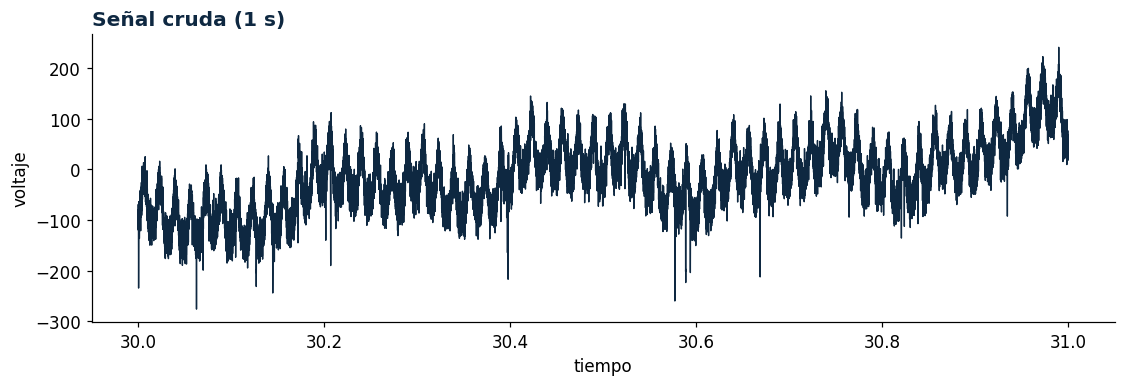

In [4]:
def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("tiempo")                          # no olvides las unidades
    plt.ylabel("voltaje")


ver(cruda, "Señal cruda (1 s)", t0=30.0, t1=31.0)


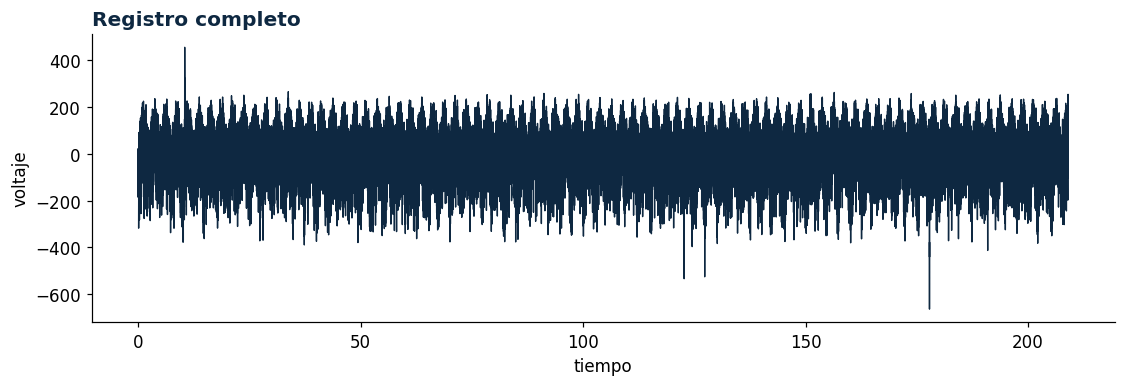

In [5]:
# Su código aquí: los otros dos zooms (50 ms y el registro completo).
def ver(x, titulo, t0=0.0, t1=109.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("tiempo")                          # no olvides las unidades
    plt.ylabel("voltaje")


ver(cruda, "Registro completo", t0=0.0, t1=209.0)

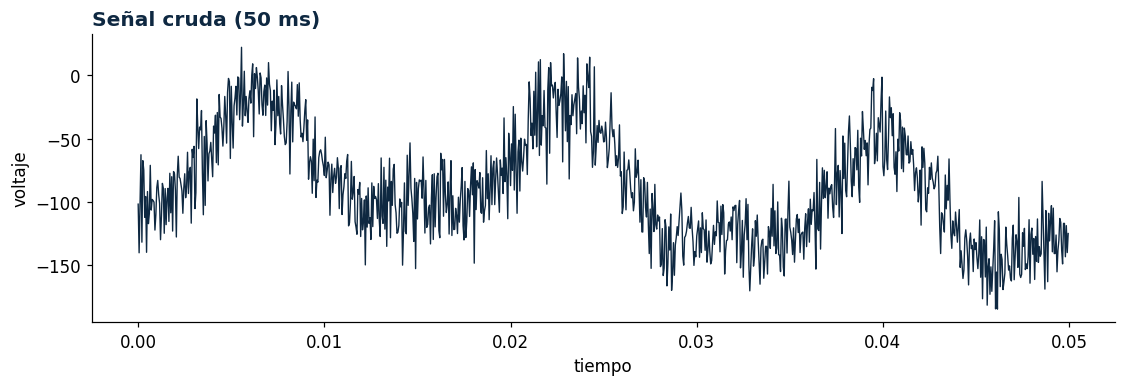

In [6]:
def ver(x, titulo, t0=0.0, t1=0.05, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("tiempo")                          # no olvides las unidades
    plt.ylabel("voltaje")


ver(cruda, "Señal cruda (50 ms)", t0=0.0, t1=0.05)

**Los tres problemas que encontramos:**

1. Ruido producido por red electrica (ventana 1 seg)
2. Ruido por movimiento del electrodo
3. deriva lenta (frecuencia de 0,4Hz)

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos
en la Sesión 3?

El registro completo es imposible si quiera ver el lugar de cada spike, la honda eliptica producida por el movimiento del cable junto con la observación de todos los registros

---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_


> hora se necesita hacer un espectro de potencia que tenga una funcion que use espectro(), a la cual las entradas seran x(array de voltaje), fs(frecuencia de muestreo), etiqueta(titulo), fmax=500.

>de salida debe dar dos arrays f (frecuencia, Hz) y P(potencia en cada frecuencia.

>como: con scipy.signal.welch y nperseg=8192; graficar solo hasta fmax, con el eje y en escala logarítmica (plt.semilogy), ejes rotulados con unidades

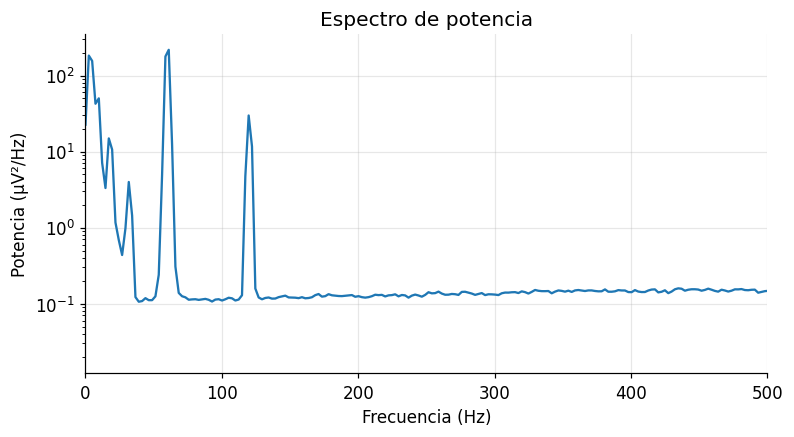

Pico dominante entre 40 y 200 Hz: 61.0 Hz


In [7]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
# Al final tienen que quedar definidas estas dos variables:

def espectro(x, fs, etiqueta, fmax=500):
    f, P = welch(x, fs=fs, nperseg=8192)
    # Quedarnos solamente con las frecuencias hasta fmax
    # mascara = f <= fmax
    #f = f[mascara]
    #P = P[mascara]
    plt.figure(figsize=(8, 4))
    plt.semilogy(f, P)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Potencia (µV²/Hz)")
    plt.title(etiqueta)
    plt.xlim(0, fmax)
    plt.grid(True, alpha=0.3)
    plt.show()
    return f, P


# Cargar la señal cruda
with h5py.File(ARCHIVO, "r") as datos:
    x = datos["registro/canal_0"][:] * datos.attrs["escala_uV_por_bit"]
    fs = datos.attrs["frecuencia_muestreo_hz"]

# Aplicar la función a la señal cruda
f, P = espectro(x, fs, "Espectro de potencia", fmax=500)


# Pico dominante entre 40 y 200 Hz
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])

print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

In [8]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


In [9]:
# Resolución
print("Resolución del espectro:", f[1] - f[0], "Hz")

Resolución del espectro: 2.44140625 Hz


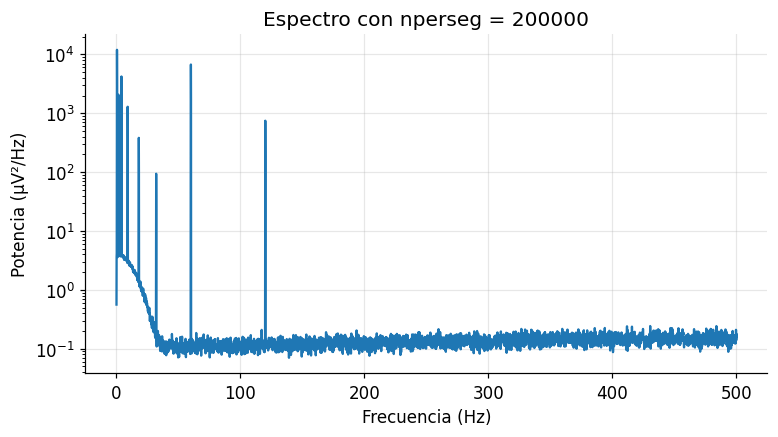

In [10]:
f_largo, P_largo = welch(x, fs=20000, nperseg=200000)

m = f_largo <= 500

plt.figure(figsize=(8, 4))
plt.semilogy(f_largo[m], P_largo[m])
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia (µV²/Hz)")
plt.title("Espectro con nperseg = 200000")
plt.grid(True, alpha=0.3)
plt.show()

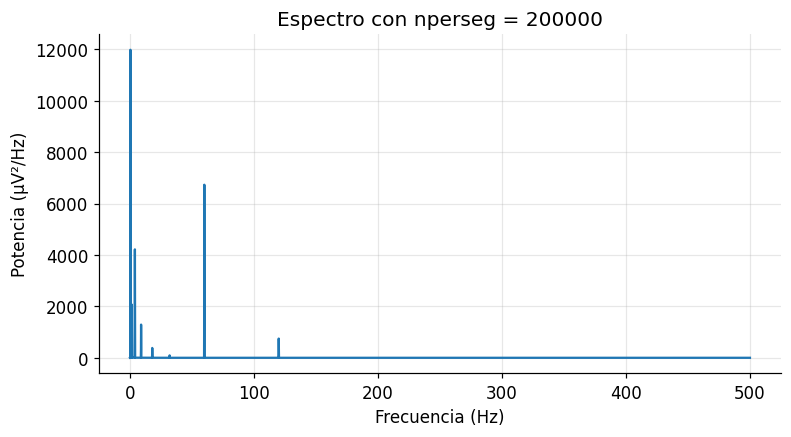

In [11]:
f_largo, P_largo = welch(x, fs=20000, nperseg=200000)

m = f_largo <= 500

plt.figure(figsize=(8, 4))
plt.plot(f_largo[m], P_largo[m])
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia (µV²/Hz)")
plt.title("Espectro con nperseg = 200000")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# duracion del segmento
duracion_segmento = 8192 / 20000
por_ciclo= (duracion_segmento/2.5)*100
print (por_ciclo,"%")

16.384 %


In [13]:
#duracion editado a 200000
dmodi=200000/20000
print(dmodi)
por_ciclo_mod= (dmodi/2.5)
print (por_ciclo_mod,"ciclos completos")

10.0
4.0 ciclos completos


**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_
 - La resolución en este caso dió 2,44
 - El sgundo pico se llama segundo armonico, el que surge a partir de las propias sobregiones que tienen el cerebro las cuales tienen su propia resonancia (Heinrichs-Graham & Wilson, 2012), generando que esta frencuencia cerebral resuene justo al doble de la frecuencia fundamental del estimulo.
 - al realizarlo con la información original vemos que se obtine al rededor de un 16% de un ciclo completo, o sea ni la mitad. Por otro lado, al tenerlo modificado el número por segundo, obtenemos que completa 4 ciclos completos.
 - Permite visualizar componentes con potencias que tienen varios órdenes de magnitud y con la escala lineal los componentes pequeños quedan ocultos

 **Referencias**
 Heinrichs-Graham, E., & Wilson, T. W. (2012). Presence of strong harmonics during visual entrainment: A magnetoencephalography study. Biological Psychology, 91, 59–64. https://doi.org/10.1016/j.biopsycho.2012.04.008

## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt:_
> Crea una función llamada filtrar() para filtrar una señal. La función debe recibir como entradas x (señal), fs (frecuencia de muestreo), baja=None (frecuencia de corte inferior), alta=None (frecuencia de corte superior) y orden=3. Debe devolver la señal filtrada, manteniendo el mismo tamaño que x. Usa un filtro Butterworth. Si solamente se proporciona alta, debe funcionar como un filtro pasa-bajos. Si solamente se proporciona baja, debe funcionar como un filtro pasa-altos. Si se proporcionan baja y alta, debe funcionar como un filtro pasa-banda. El filtrado debe realizarse con fase cero utilizando filtfilt o sosfiltfilt, para evitar desplazar temporalmente la señal. Las frecuencias de corte deben normalizarse respecto a la frecuencia de Nyquist (fs/2).

<Figure size 1320x374 with 0 Axes>

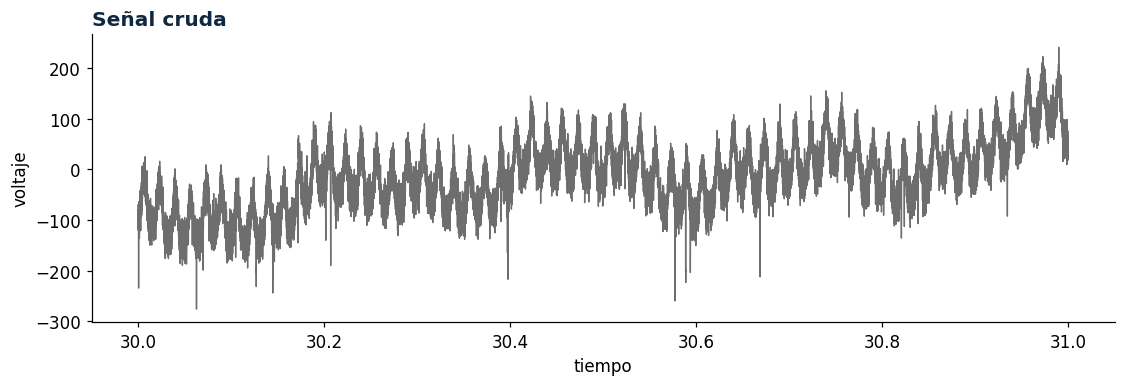

<Figure size 1320x374 with 0 Axes>

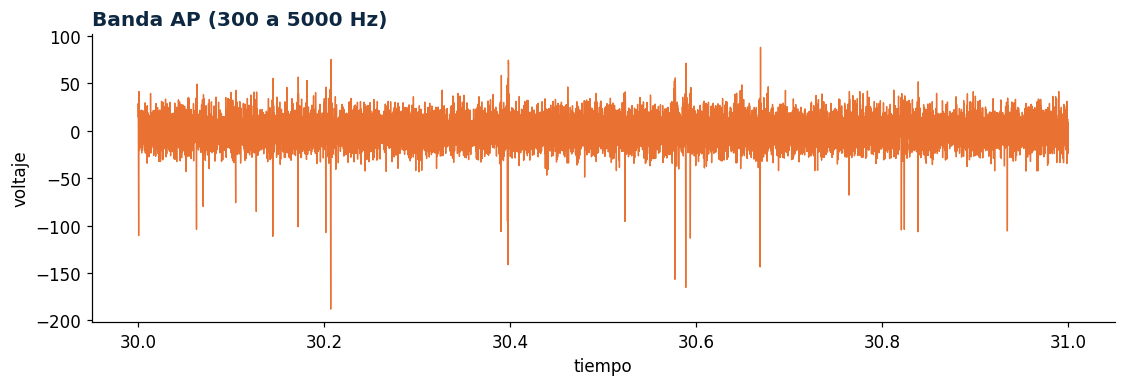

In [14]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.
def filtrar(x, fs, baja=None, alta=None, orden=3):

    nyquist = fs / 2

    # Pasa-bajos
    if baja is None and alta is not None:
        corte = alta / nyquist
        b, a = butter(orden, corte, btype="lowpass")

    # Pasa-altos
    elif baja is not None and alta is None:
        corte = baja / nyquist
        b, a = butter(orden, corte, btype="highpass")

    # Pasa-banda
    elif baja is not None and alta is not None:
        cortes = [baja / nyquist, alta / nyquist]
        b, a = butter(orden, cortes, btype="bandpass")

    else:
        raise ValueError("Debe especificar baja, alta o ambas.")

    # Filtrado de fase cero
    return filtfilt(b, a, x)

AP = filtrar(cruda, fs, baja=300, alta=5000)       # pasa-banda de 300 a 5000 Hz sobre la señal cruda

plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [15]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_
 - El pasa-banda se fijo en 300Hz lo que elimina por completo todas las dfrecuencias por debajo de esa. Por lo cual la contaminación de los 60Hz se atenua por completo sin necesidad de usar un notch.
 - La deriva lenta se atenuo por completo por el filtro de corte en 300Hz, haciendo que la linea sea más plana al nivel del 0. Los artefactos se disminuyeron casi en su totalidad, puesto que la mayor parte de su energía se concentraba en frecuencias por debajo del rango AP

- El notch lo usaría entonces cuando la señal comparte el mismo rango espectral que el ruido, para así eliminar este ruido sin destruir la señal util.


### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

- respuesta: El código sirve porque iirnotch recibe correctamente la frecuencia de muestreo fs

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

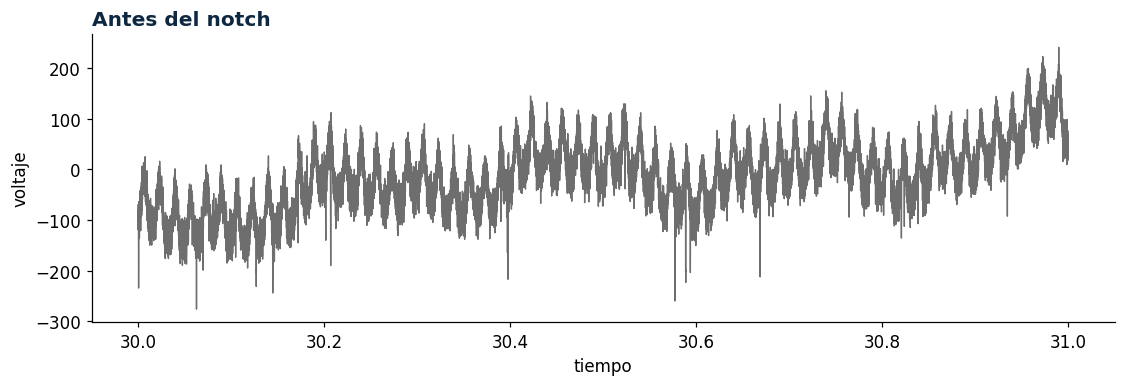

<Figure size 1320x374 with 0 Axes>

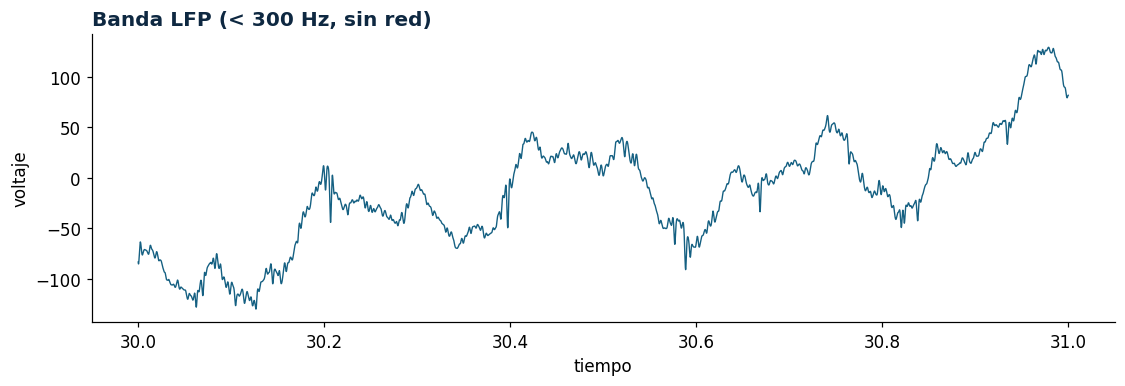

In [16]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.
def notch(x, f0, fs, Q=30):
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)
    y = filtfilt(b, a, x)
    return y

sin_red = notch(notch(cruda, f0=60, fs=fs), f0=120, fs=fs)    # la señal cruda sin ruido de red
LFP     = filtrar(sin_red, fs, alta=300)            # pasa-bajos de 300 Hz sobre sin_red

plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

In [17]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_

- al notch en 9Hz sufre cambios en la forma de la señal, reduciendo algunos picos, lo que quiere decir que probablemtene este borrando componentes de la señal biologica
- En el caso de el Q se puede ver que un Q grande (Q=30) se ven afectadas las más pequeñas al rededor de nuestra frecuencia. Por otro lado el notch pequeño Elimina bandas mucho mayores al rededor de 60Hz, es decir, que elimina información útil al rededor de los 60Hz.
- Lo que se cuela en el corte de los 100Hz es basicamente ruido que esta entre los 100 a 300Hz que normalmente no queremos ver en los potenciales. Lo que podría mezclar la información que se tenga en esacalas temporales.
Con el corte de 800Hz la forma de los disparos cambia porque se esta borrando lo que hay entre 300 y 800Hz lo que hace que se pierda parte del contenido de los potenciales, por ende no se ve una sola frecuencia
- El corte inferior de 300 Hz se seleccionó porque elimina efectivamente el LFP y el ruido de red (60 Hz) sin atenuar la energía principal de los potenciales de acción buscados.
- El diagnóstico va antes del filtrado porque primero debemos identificar qué componentes contiene la señal para elegir cortes que eliminen ruido sin destruir información que queremos.

<Figure size 1320x374 with 0 Axes>

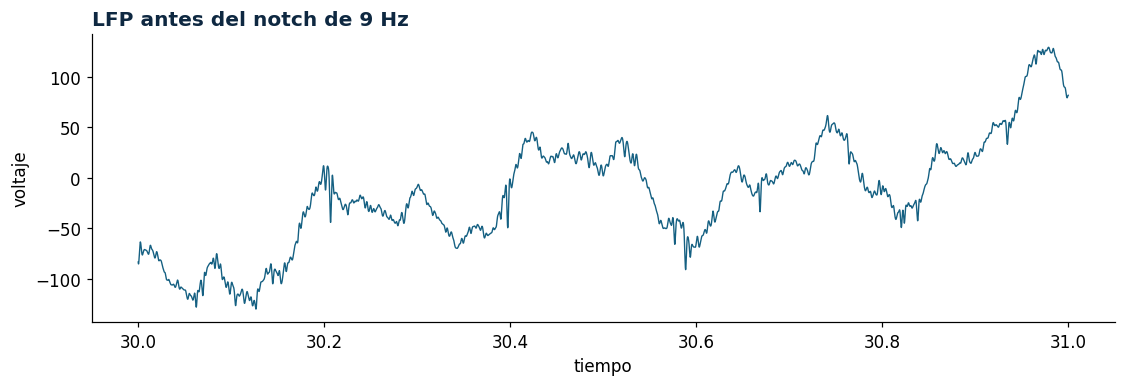

<Figure size 1320x374 with 0 Axes>

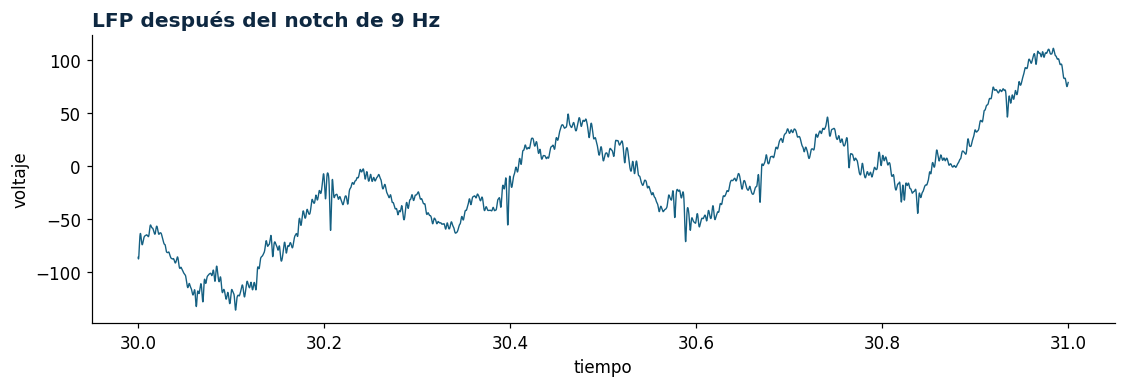

In [18]:
# notch en 9 Hz
LFP_9Hz = notch(LFP, f0=9, fs=fs)
plt.figure()
ver(LFP, "LFP antes del notch de 9 Hz", t0=30.0, t1=31.0, color=TEAL)

plt.figure()
ver(LFP_9Hz, "LFP después del notch de 9 Hz", t0=30.0, t1=31.0, color=TEAL)

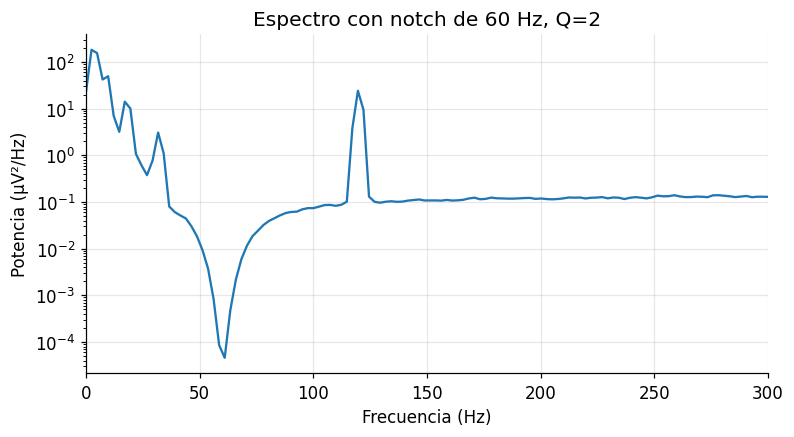

In [19]:
# notch 60Hz Q=2
sin_60_Q2 = notch(cruda, f0=60, fs=fs, Q=2)

f_Q2, P_Q2 = espectro(sin_60_Q2, fs, "Espectro con notch de 60 Hz, Q=2", fmax=300)

<Figure size 1320x374 with 0 Axes>

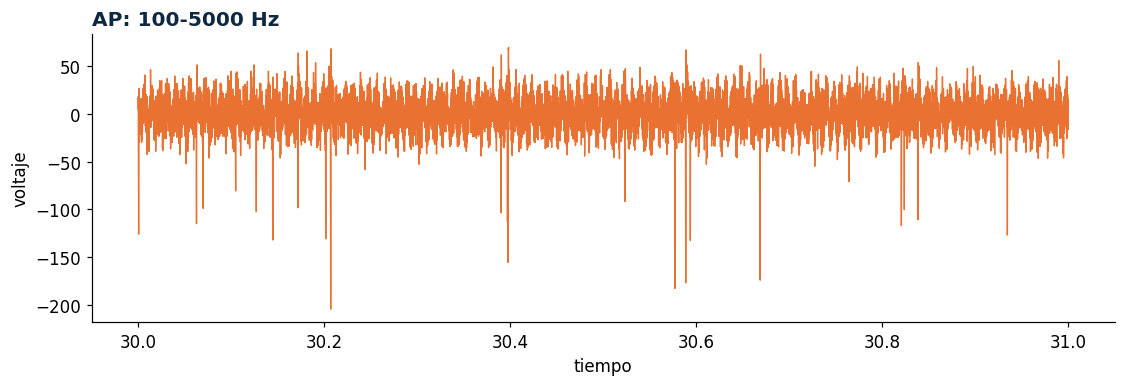

<Figure size 1320x374 with 0 Axes>

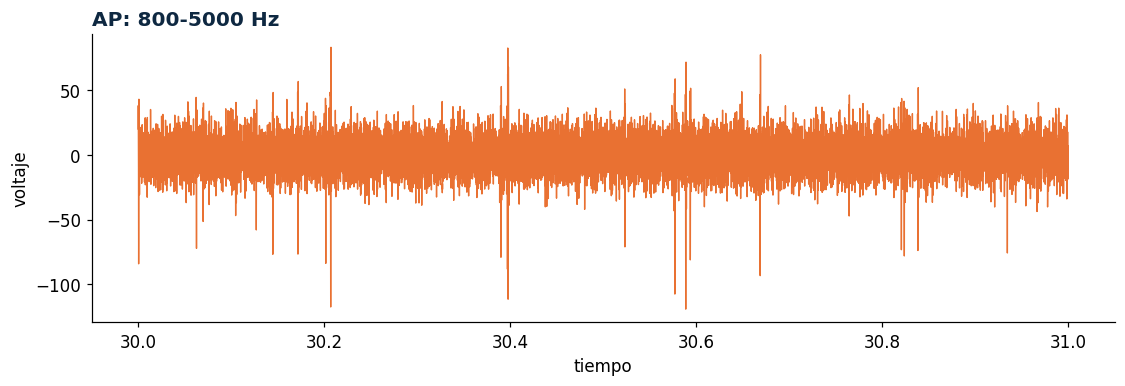

In [20]:
#Banda AP

AP_100 = filtrar(cruda, fs, baja=100, alta=5000)
AP_800 = filtrar(cruda, fs, baja=800, alta=5000)
plt.figure()
ver(AP_100, "AP: 100-5000 Hz", t0=30.0, t1=31.0, color=ORANGE)

plt.figure()
ver(AP_800, "AP: 800-5000 Hz", t0=30.0, t1=31.0, color=ORANGE)

---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [21]:
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """Devuelve los índices de las muestras donde hay un potencial de acción."""

    sigma = np.median(np.abs(x)) / 0.6745
    umbral = -k * sigma
    cruza = x < umbral
    indices = []
    i = 0
    while i < len(x):
        if cruza[i]:
            inicio = i
            while i < len(x) and cruza[i]:
                i += 1
            final = i
            indice = inicio + np.argmin(x[inicio:final])
            indices.append(indice)
        else:
            i += 1

    muerto_muestras = int(round(muerto_ms * 1e-3 * fs))
    aceptados = []

    for indice in indices:
        if len(aceptados) == 0:
            aceptados.append(indice)
        elif indice - aceptados[-1] >= muerto_muestras:
            aceptados.append(indice)

    return np.asarray(aceptados, dtype=int)



indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5461 disparos en 210 s (26.0 por segundo)


In [22]:
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

detectados: 5461 disparos en 210 s (26.0 por segundo)


In [23]:
sigma = np.median(np.abs(AP)) / 0.6745
umbral = -4.5 * sigma

print("sigma:", sigma, "µV")
print("umbral:", umbral, "µV")
print("mínimo AP:", np.min(AP), "µV")
print("máximo AP:", np.max(AP), "µV")

print("muestras por debajo del umbral:", np.sum(AP < umbral))

sigma: 13.526275649370088 µV
umbral: -60.8682404221654 µV
mínimo AP: -334.43079564837007 µV
máximo AP: 139.62841210681148 µV
muestras por debajo del umbral: 26337


In [24]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

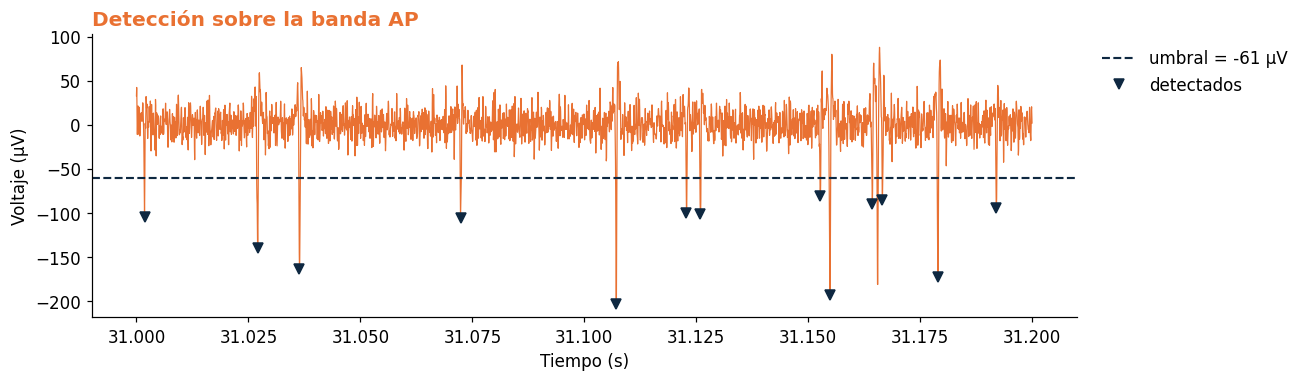

In [25]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(d/fs, AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")  # ¿tiempo y voltaje de qué?
plt.xlabel("Tiempo (s)"); plt.ylabel("Voltaje (µV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_

> Crea una función llamada emparejar(detectados_s, reales_s, tol_ms=1.0) que reciba dos arrays ordenados de tiempos en segundos: detectados_s, que contiene los tiempos de los disparos detectados, y reales_s, que contiene los tiempos reales de los disparos. Debe devolver tres enteros: VP (verdaderos positivos), FP (falsos positivos) y FN (falsos negativos).

Para decidir si una detección coincide con un disparo real, usa una ventana de tolerancia de tol_ms milisegundos. Dos tiempos cuentan como el mismo disparo si su diferencia absoluta es menor o igual que tol_ms convertido a segundos.

Ten en cuenta que cada disparo real puede emparejarse con una sola detección. Una vez que un disparo real ha sido emparejado, no puede volver a utilizarse para contar otra detección como verdadero positivo. Como los tiempos vienen ordenados, recorre ambos arrays de forma ordenada y realiza el emparejamiento sin reutilizar elementos.
Al final:
- VP = número de detecciones emparejadas con un disparo real.
- FP = detecciones que no pudieron emparejarse con ningún disparo real.
- FN = disparos reales que no fueron emparejados.

Devuelve exactamente (VP, FP, FN).

In [26]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()     # los tiempos reales, en segundos

# Su código aquí: la función emparejar(), y con ella los tres números.
def emparejar(detectados_s, reales_s, tol_ms=1.0):
    tol_s = tol_ms / 1000

    VP = 0
    FP = 0
    FN = 0
    i = 0
    j = 0
    while i < len(detectados_s) and j < len(reales_s):
      diferencia = detectados_s[i] - reales_s[j]

      if abs(diferencia) <= tol_s:
        VP += 1
        i += 1
        j += 1
      elif detectados_s[i] < reales_s[j]:
        FP += 1
        i += 1

      else:
        FN += 1
        j += 1

    FP += len(detectados_s) - i
    FN += len(reales_s) - j

    return VP, FP, FN

VP, FP, FN = emparejar(tiempos, reales)

print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5457   FP = 4   FN = 166
precisión     = 0.999
exhaustividad = 0.970


In [27]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5461 spikes
  En realidad hay    5623
  Aciertos           5457   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.0%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?

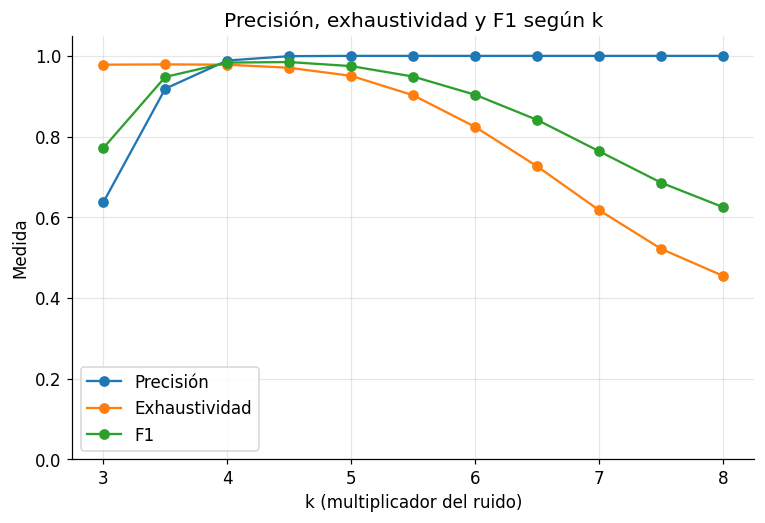

In [28]:
# Su código aquí.
ks = np.arange(3, 8.1, 0.5)

precisiones = []
exhaustividades = []
f1s = []

for k in ks:
    indices_k = detectar_spikes(AP, fs, k=k)
    tiempos_k = indices_k / fs

    VP, FP, FN = emparejar(tiempos_k, reales)

    precision = VP / (VP + FP)
    exhaustividad = VP / (VP + FN)

    if precision + exhaustividad > 0:
        f1 = 2 * precision * exhaustividad / (precision + exhaustividad)
    else:
        f1 = 0

    precisiones.append(precision)
    exhaustividades.append(exhaustividad)
    f1s.append(f1)

plt.figure(figsize=(8, 5))
plt.plot(ks, precisiones, marker="o", label="Precisión")
plt.plot(ks, exhaustividades, marker="o", label="Exhaustividad")
plt.plot(ks, f1s, marker="o", label="F1")

plt.xlabel("k (multiplicador del ruido)")
plt.ylabel("Medida")
plt.title("Precisión, exhaustividad y F1 según k")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

In [29]:
# Su código aquí.
# Intervalos entre disparos reales consecutivos
intervalos = np.diff(reales)

# Convertir a milisegundos
intervalos_ms = intervalos * 1000

# Contar intervalos menores que el período muerto
cortos = intervalos_ms < 1.5

print(f"Disparos reales separados por menos de 1.5 ms: {np.sum(cortos)}")
print(f"FN con muerto_ms=1.5: {FN}")

indices_04 = detectar_spikes(AP, fs, k=4.5, muerto_ms=0.4)

tiempos_04 = indices_04 / fs

VP_04, FP_04, FN_04 = emparejar(tiempos_04, reales)

precision_04 = VP_04 / (VP_04 + FP_04)
exhaustividad_04 = VP_04 / (VP_04 + FN_04)

print(f"VP = {VP_04}")
print(f"FP = {FP_04}")
print(f"FN = {FN_04}")
print(f"precisión = {precision_04:.3f}")
print(f"exhaustividad = {exhaustividad_04:.3f}")


Disparos reales separados por menos de 1.5 ms: 122
FN con muerto_ms=1.5: 3069
VP = 5519
FP = 7
FN = 104
precisión = 0.999
exhaustividad = 0.982


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

- El período muerto no explica la mayoría de los FN hay 122 disparos reales que están separados por menos de 1.5 ms, en contraste a 3069 FN que se obtuvieron inicialmente. Por lo tanto, la mayoría de los FN se debe a disparos que no cruzaron el umbral. Finalmente nos quedariamos con un período muerto de 0.4 ms porque aumenta la exhaustividad de 0.970 a 0.982 y reduce los FN de 166 a 104, mientras que la precisión prácticamente no cambia.

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [ ]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

In [30]:
# Su código aquí.
# Al final debe quedar definida la matriz de formas:
pre_ms = 0.7
post_ms = 1.3
pre = int(round(pre_ms * fs / 1000))
post = int(round(post_ms * fs / 1000))
formas_lista = []
indices_validos = []
tiempos_validos = []
for indice, tiempo in zip(indices, tiempos):
    inicio = indice - pre
    final = indice + post
    if inicio < 0 or final > len(AP):
        continue
    # Extraer la forma de onda
    forma = AP[inicio:final]

    formas_lista.append(forma)
    indices_validos.append(indice)
    tiempos_validos.append(tiempo)

formas = np.asarray(formas_lista) # matriz n_disparos x n_muestras

indices = np.asarray(indices_validos, dtype=int)
tiempos = np.asarray(tiempos_validos)

# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.

In [31]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

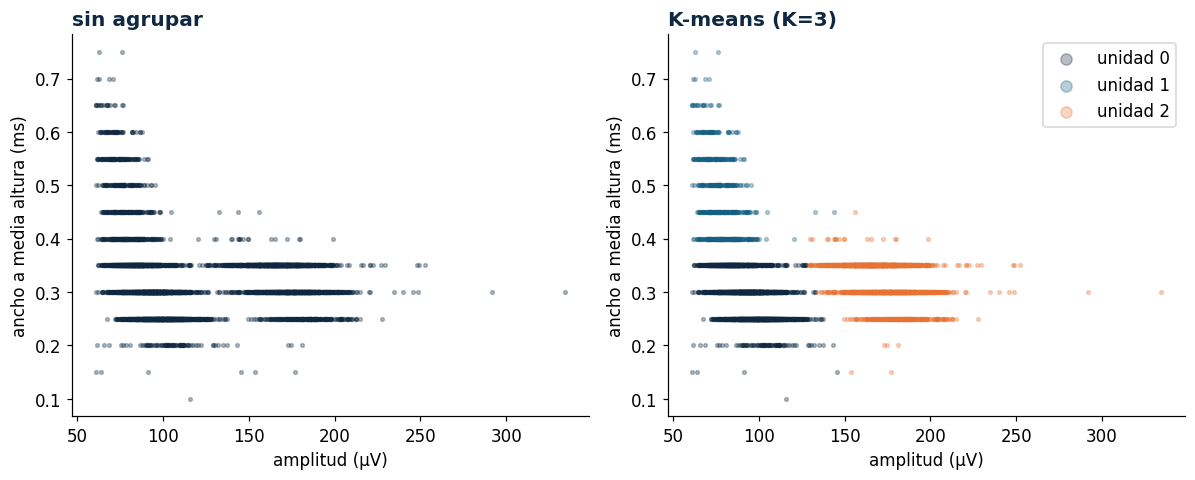

In [32]:
# Su código aquí: características, gráfico de dispersión y agrupación.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def ancho_a_media_altura(forma, fs):
    """Ancho (ms) del valle negativo de una forma de onda, medido a mitad de su profundidad."""
    i_min = np.argmin(forma)
    nivel = forma[i_min] / 2            # a mitad de camino entre 0 y el mínimo

    izq = i_min
    while izq > 0 and forma[izq] < nivel:
        izq -= 1
    der = i_min
    while der < len(forma) - 1 and forma[der] < nivel:
        der += 1

    return (der - izq) / fs * 1000      # muestras -> ms

# --- características: una fila de "formas" = una forma de onda ---
amplitud = -formas.min(axis=1)                                      # µV
anchos   = np.array([ancho_a_media_altura(f, fs) for f in formas])  # ms

# --- escalar y agrupar ---
caracteristicas     = np.column_stack([amplitud, anchos])
caracteristicas_esc = StandardScaler().fit_transform(caracteristicas)
etiquetas = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(caracteristicas_esc)

# --- gráfico: antes y después de agrupar ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.scatter(amplitud, anchos, s=6, alpha=0.3, color=NAVY)
ax1.set_title("sin agrupar", color=NAVY, fontweight="bold", loc="left")

for grupo, color in zip([0, 1, 2], [NAVY, TEAL, ORANGE]):
    m = etiquetas == grupo
    ax2.scatter(amplitud[m], anchos[m], s=6, alpha=0.3, color=color, label=f"unidad {grupo}")
ax2.set_title("K-means (K=3)", color=NAVY, fontweight="bold", loc="left")
ax2.legend(markerscale=3)

for ax in (ax1, ax2):
    ax.set_xlabel("amplitud (µV)")
    ax.set_ylabel("ancho a media altura (ms)")

plt.tight_layout()    # un identificador de unidad por disparo (0/1/2, 'a'/'b'/'c', da igual)

In [33]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           2       2143       33        1
           0         15     2550      116
           1          1      115      483

  Acierto   94.9%  ███████████████████████████·

  ▸ Separación correcta.


Grcias a pasar el codigo de la ia pude ayudar a tener el grafico un poco mas claro con la ayuda de hacerlo con ciertos colores para la identificacion, a parte de eso entendi que debido a que junta tantos disparos las 2 neuronas se ven casi identicas, por lo que cuando se agrega el ancho a media altura esos 2 grupos se separan mucho mejor

### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | |
| con las dos características que elegimos | |

_Explicación:_

In [34]:
etiquetas_amplitud = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(amplitud.reshape(-1, 1))

print("== Solo amplitud ==")
acierto_amplitud = v.verificar_unidades(indices / fs, etiquetas_amplitud)

print("\n== Amplitud + ancho a media altura ==")
acierto_dos = v.verificar_unidades(indices / fs, etiquetas)

== Solo amplitud ==
  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2106       33        2
           2         53     1434       53
           0          0     1231      545

  Acierto   74.9%  █████████████████████·······

  ▸ Casi. Dos de tus unidades se están mezclando: mira la matriz
    y pregúntate qué característica NO estás usando.

== Amplitud + ancho a media altura ==
  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           2       2143       33        1
           0         15     2550      116
           1          1      115      483

  Acierto   94.9%  ███████████████████████████·

  ▸ Separación correcta.


---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

a) violaciones (todos juntos): 0.79 %  (43 de 5460 intervalos)

b) violaciones por unidad:
   unidad 0: 0.00 %  (0 de 2684 intervalos, n=2685)
   unidad 1: 0.00 %  (0 de 598 intervalos, n=599)
   unidad 2: 0.09 %  (2 de 2176 intervalos, n=2177)

d) violaciones (todos juntos, muerto_ms=0.4): 2.01 %  (111 de 5525 intervalos)
   65 disparos que 0.4 ms encuentra y 1.5 ms no
   violaciones por unidad (0.4 ms, solo disparos con etiqueta heredada):
   unidad 0: 0.00 %  (n=2685)
   unidad 1: 0.00 %  (n=599)
   unidad 2: 0.09 %  (n=2177)


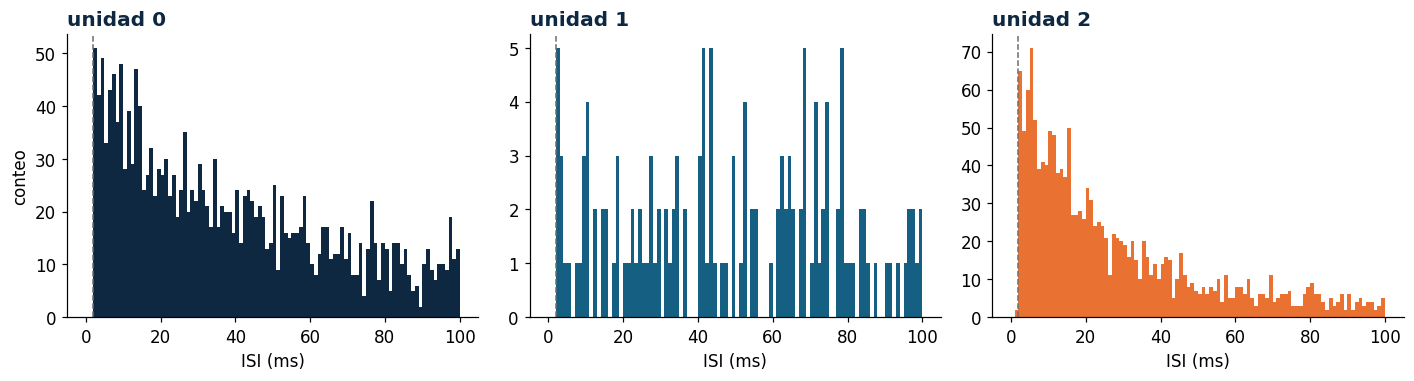

In [35]:
# Su código aquí.
# --- a) ISI de todos los disparos juntos (detección original) ---
isi_todos = np.diff(np.sort(tiempos)) * 1000                     # ms
frac_todos = np.mean(isi_todos < 2.0)
print(f"a) violaciones (todos juntos): {frac_todos*100:.2f} %  "
      f"({np.sum(isi_todos < 2.0)} de {len(isi_todos)} intervalos)")

# --- b) ISI por unidad ---
print("\nb) violaciones por unidad:")
for u in np.unique(etiquetas):
    t_u = np.sort(tiempos[etiquetas == u])
    isi_u = np.diff(t_u) * 1000
    frac = np.mean(isi_u < 2.0)
    print(f"   unidad {u}: {frac*100:.2f} %  "
          f"({np.sum(isi_u < 2.0)} de {len(isi_u)} intervalos, n={len(t_u)})")

# --- c) histogramas de ISI por unidad ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
colores = dict(zip(np.unique(etiquetas), [NAVY, TEAL, ORANGE]))
for ax, u in zip(axes, np.unique(etiquetas)):
    isi_u = np.diff(np.sort(tiempos[etiquetas == u])) * 1000
    ax.hist(isi_u, bins=np.arange(0, 101, 1), color=colores[u])
    ax.axvline(2.0, color=GRAY, ls="--", lw=1)
    ax.set_title(f"unidad {u}", color=NAVY, fontweight="bold", loc="left")
    ax.set_xlabel("ISI (ms)")
axes[0].set_ylabel("conteo")
plt.tight_layout()

# --- d) lo mismo, con la detección de muerto_ms=0.4 (indices_04/tiempos_04 de F3) ---
isi_todos_04 = np.diff(np.sort(tiempos_04)) * 1000
frac_todos_04 = np.mean(isi_todos_04 < 2.0)
print(f"\nd) violaciones (todos juntos, muerto_ms=0.4): {frac_todos_04*100:.2f} %  "
      f"({np.sum(isi_todos_04 < 2.0)} de {len(isi_todos_04)} intervalos)")

# indices_04 no pasó por el agrupamiento de H, así que a cada disparo nuevo le
# heredamos la etiqueta del disparo original más cercano en el tiempo (si hay
# uno a <= 0.3 ms). Los que no tienen ninguno cerca son disparos que el
# detector de 1.5 ms nunca vio por separado: los fusionó con su vecino.
def heredar_etiqueta(tiempos_nuevos, tiempos_orig, etiquetas_orig, tol_ms=0.3):
    """A cada tiempo nuevo le asigna la etiqueta del tiempo original más cercano,
    si cae a <= tol_ms; si no, np.nan (disparo sin equivalente anterior)."""
    tol_s = tol_ms / 1000
    pos = np.clip(np.searchsorted(tiempos_orig, tiempos_nuevos), 1, len(tiempos_orig) - 1)
    d_izq = np.abs(tiempos_nuevos - tiempos_orig[pos - 1])
    d_der = np.abs(tiempos_nuevos - tiempos_orig[pos])
    mas_cercano = np.where(d_izq <= d_der, pos - 1, pos)
    dist = np.minimum(d_izq, d_der)
    return np.where(dist <= tol_s, etiquetas_orig[mas_cercano], np.nan)

etiquetas_04 = heredar_etiqueta(tiempos_04, tiempos, etiquetas)
nuevos = np.isnan(etiquetas_04)
print(f"   {nuevos.sum()} disparos que 0.4 ms encuentra y 1.5 ms no")

print("   violaciones por unidad (0.4 ms, solo disparos con etiqueta heredada):")
for u in np.unique(etiquetas):
    t_u = np.sort(tiempos_04[etiquetas_04 == u])
    isi_u = np.diff(t_u) * 1000
    frac = np.mean(isi_u < 2.0) if len(isi_u) else np.nan
    print(f"   unidad {u}: {frac*100:.2f} %  (n={len(t_u)})")

**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | |
| unidad 1 | |
| unidad 2 | |
| unidad 3 | |

¿Alguna unidad está contaminada? ¿Cuál y por qué?
ninguna de las unidades muestra una contaminacion importante. Por otra parte la unidad 2 presenta una tasa de violacion de 0,09% aunque esto sigue siendo una tasa baja y que se puede considerar aceptable, lo que sugiere una separacion de las unidades bastante clara.
¿Qué pasó al bajar el período muerto a 0,4 ms?
Al bajar el período muerto a 0.4 ms, la tasa de violaciones para todos los disparos juntos aumentó. Esto indica que un mayor número de disparos muy cercanos entre sí fueron detectados cuando el período muerto fue más corto. El sistema identificó 65 disparos que el detector con un período muerto de 1.5 ms no habría encontrado. Estos disparos adicionales, que antes se habrían descartado o fusionado con otros, ahora contribuyen a un aumento en la tasa general de violaciones. Sin embargo, las tasas de violación por unidad permanecieron muy bajas, lo que sugiere que la mayoría de los nuevos disparos detectados corresponden a eventos que ocurren muy cerca entre diferentes unidades, o dentro de la misma unidad pero en momentos que no violan significativamente el período refractario intrínseco de una sola neurona.


---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [36]:
# Su código aquí.
# Pista: with h5py.File(ARCHIVO, "r") as f: ... y no olviden f["estimulos"].attrs

with h5py.File(ARCHIVO, "r") as f:
    estimulos = f["estimulos"]

    inicios     = estimulos["tiempo_inicio_s"][:]                 # s, inicio de cada ENSAYO
    condiciones = estimulos["condicion"][:].astype(str)           # bytes -> 'A' / 'B' / 'C'
    t_pre       = float(estimulos.attrs["duracion_pre_s"])        # s, pre-estímulo
    t_est       = float(estimulos.attrs["duracion_estimulo_s"])   # s, estímulo
    t_post      = float(estimulos.attrs["duracion_post_s"])       # s, no la pide el ejercicio, pero sirve para L/M

n_ensayos = len(inicios)
print(f"ensayos: {n_ensayos}")
for c in np.unique(condiciones):
    print(f"  condición {c}: {np.sum(condiciones == c)} ensayos")

print(f"\nduración del ensayo: {t_pre + t_est + t_post:.1f} s "
      f"(pre {t_pre} + estímulo {t_est} + post {t_post})")
print(f"primeras 10 condiciones: {list(condiciones[:10])}")

ensayos: 60
  condición A: 20 ensayos
  condición B: 20 ensayos
  condición C: 20 ensayos

duración del ensayo: 3.0 s (pre 1.0 + estímulo 0.5 + post 1.5)
primeras 10 condiciones: [np.str_('B'), np.str_('B'), np.str_('C'), np.str_('A'), np.str_('A'), np.str_('A'), np.str_('C'), np.str_('A'), np.str_('C'), np.str_('B')]


In [37]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [38]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    relativos = []
    for inicio_ensayo in inicios:
        t_estimulo = inicio_ensayo + t_pre      # el estímulo empieza t_pre DESPUÉS del ensayo
        rel = tiempos - t_estimulo
        rel = rel[(rel >= ventana[0]) & (rel <= ventana[1])]   # recortar a la ventana, no solo restar
        relativos.append(rel)
    return relativos


# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [39]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.
# Comprobación a mano: elegimos el primer ensayo y la primera unidad.
i_ensayo = 0
u = np.unique(etiquetas)[0]

t_estimulo_manual = inicios[i_ensayo] + t_pre
disparos_abs = tiempos[etiquetas == u]
manual = disparos_abs - t_estimulo_manual
manual = np.sort(manual[(manual >= -1.0) & (manual <= 2.0)])

de_la_funcion = np.sort(alineados[u][i_ensayo])

print( manual[:5])
print( de_la_funcion[:5])
print("¿coinciden?", np.allclose(manual, de_la_funcion))

[-0.9995  -0.9373  -0.93015 -0.8952  -0.873  ]
[-0.9995  -0.9373  -0.93015 -0.8952  -0.873  ]
¿coinciden? True


In [40]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

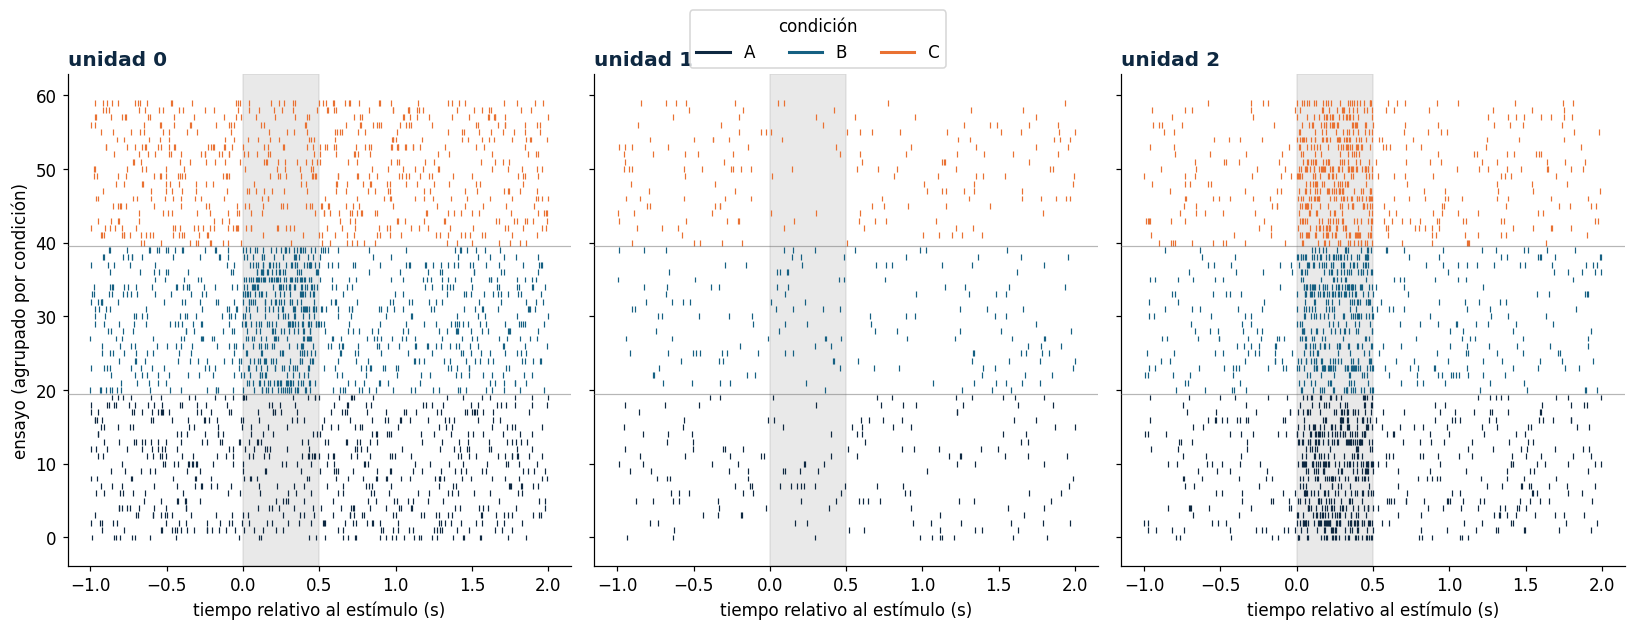

In [41]:
# Su código aquí.
condicion_color = dict(zip(np.unique(condiciones), [NAVY, TEAL, ORANGE]))

orden = np.argsort(condiciones, kind="stable")     # agrupa los ensayos por condición
cond_ordenadas = condiciones[orden]
cambios_de_bloque = np.where(cond_ordenadas[:-1] != cond_ordenadas[1:])[0] + 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=True, sharey=True)

for ax, u in zip(axes, np.unique(etiquetas)):
    filas   = [alineados[u][i] for i in orden]
    colores = [condicion_color[condiciones[i]] for i in orden]

    ax.eventplot(filas, colors=colores, linelengths=0.8, linewidths=0.8)
    ax.axvspan(0, t_est, color=GRAY, alpha=0.15, zorder=0)          # ventana del estímulo
    for c in cambios_de_bloque:
        ax.axhline(c, color=GRAY, lw=0.8, alpha=0.5, zorder=3)      # separa bloques de condición

    ax.set_title(f"unidad {u}", color=NAVY, fontweight="bold", loc="left")
    ax.set_xlabel("tiempo relativo al estímulo (s)")

axes[0].set_ylabel("ensayo (agrupado por condición)")

handles = [plt.Line2D([0], [0], color=c, lw=2) for c in condicion_color.values()]
fig.legend(handles, condicion_color.keys(), title="condición", loc="upper center",
           ncol=len(condicion_color), bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()

**Lo que leemos en el raster:** en la unidad 0 hay una consentracion de estimulos azules en la figura gris que corresponde a cuando hubo un estimulo. en la figura 2 no se ve una respuesta muy clara a estos estimulos. en la figura 3 vemos que hubo una respuesta clara a los estimulos por parte de todos.

---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

Para la figura de un articulo eligiria la numero 3 (unidad 2) ya que es la que puede ser mas clara para el espectador ya que hace una clara comparacion entre el ruido esperado al momento de estudiar los potenciales de accion y la altura de cada spike cuando hay un estimulo, comparado con el tiempo relativo del estimulo. ya que en las demas figuras se pierde la comparacion entre todos los resultados.

In [42]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """Devuelve (centros_de_bin, tasa_en_Hz)."""
    n_bins = round((ventana[1] - ventana[0]) / ancho_bin_s)
    bordes = np.linspace(ventana[0], ventana[1], n_bins + 1)

    todos_los_disparos = np.concatenate(ensayos_alineados) if len(ensayos_alineados) else np.array([])
    cuentas, _ = np.histogram(todos_los_disparos, bins=bordes)

    centros = (bordes[:-1] + bordes[1:]) / 2
    n_ensayos = len(ensayos_alineados)
    tasa_Hz = cuentas / (n_ensayos * ancho_bin_s)     # disparos/ensayo/bin -> disparos/segundo
    return centros, tasa_Hz

In [43]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


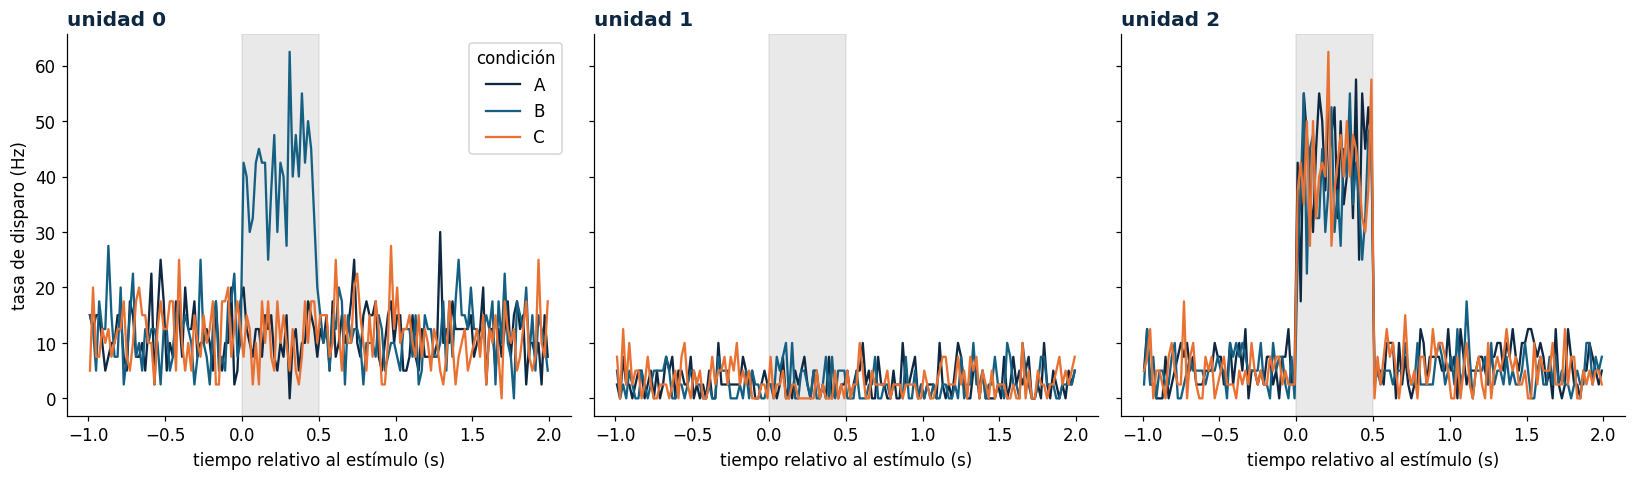

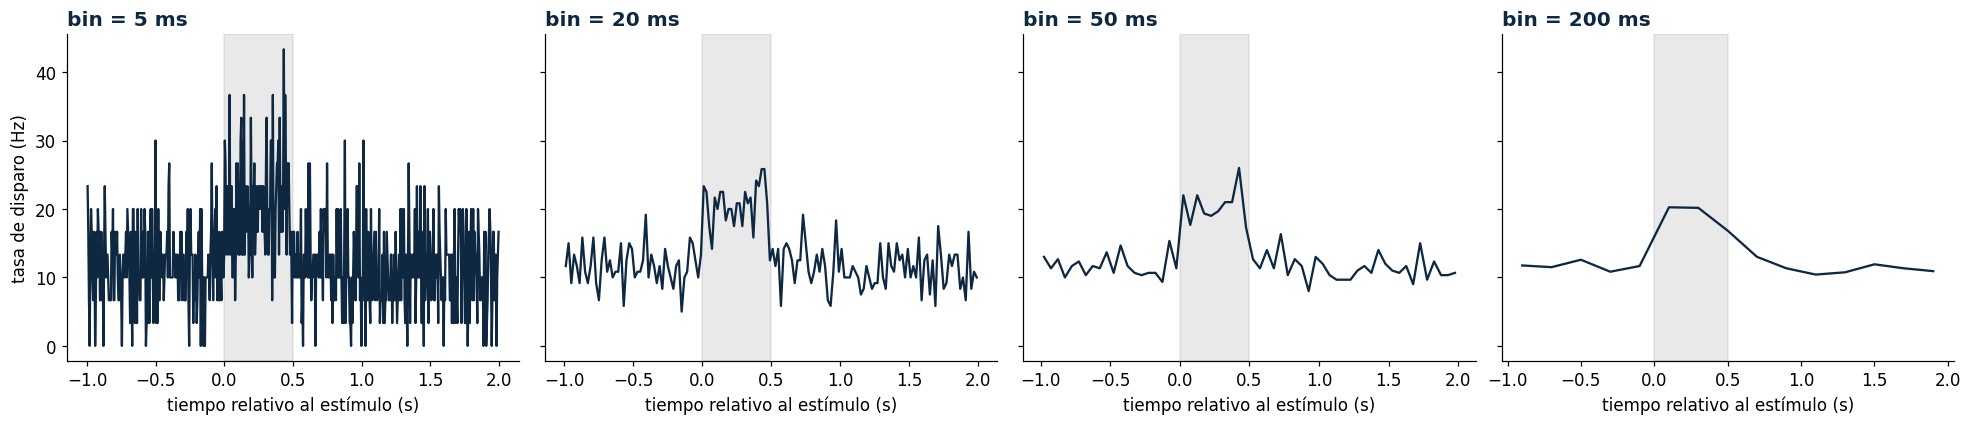

In [44]:
# Ejercicios M2 y M3: su código aquí.
# --- M2: PSTH por unidad y condición ---
ancho_bin = 0.02   # 20 ms

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, u in zip(axes, np.unique(etiquetas)):
    for cond, color in condicion_color.items():
        ensayos_cond = [alineados[u][i] for i in range(len(inicios)) if condiciones[i] == cond]
        centros, tasa = psth(ensayos_cond, (-1.0, 2.0), ancho_bin)
        ax.plot(centros, tasa, color=color, label=cond)
    ax.axvspan(0, t_est, color=GRAY, alpha=0.15, zorder=0)
    ax.set_title(f"unidad {u}", color=NAVY, fontweight="bold", loc="left")
    ax.set_xlabel("tiempo relativo al estímulo (s)")
axes[0].set_ylabel("tasa de disparo (Hz)")
axes[0].legend(title="condición")
plt.tight_layout()
plt.show()

# --- M3: efecto del ancho de bin, en la unidad que responde ---
unidad_que_responde = np.unique(etiquetas)[0]   # <-- cambien esto por la que vieron responder en L/M2

anchos_ms = [5, 20, 50, 200]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, ancho_ms in zip(axes, anchos_ms):
    centros, tasa = psth(alineados[unidad_que_responde], (-1.0, 2.0), ancho_ms / 1000)
    ax.plot(centros, tasa, color=NAVY)
    ax.axvspan(0, t_est, color=GRAY, alpha=0.15, zorder=0)
    ax.set_title(f"bin = {ancho_ms} ms", color=NAVY, fontweight="bold", loc="left")
    ax.set_xlabel("tiempo relativo al estímulo (s)")
axes[0].set_ylabel("tasa de disparo (Hz)")
plt.tight_layout()

**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

r= se lee de una manera clara

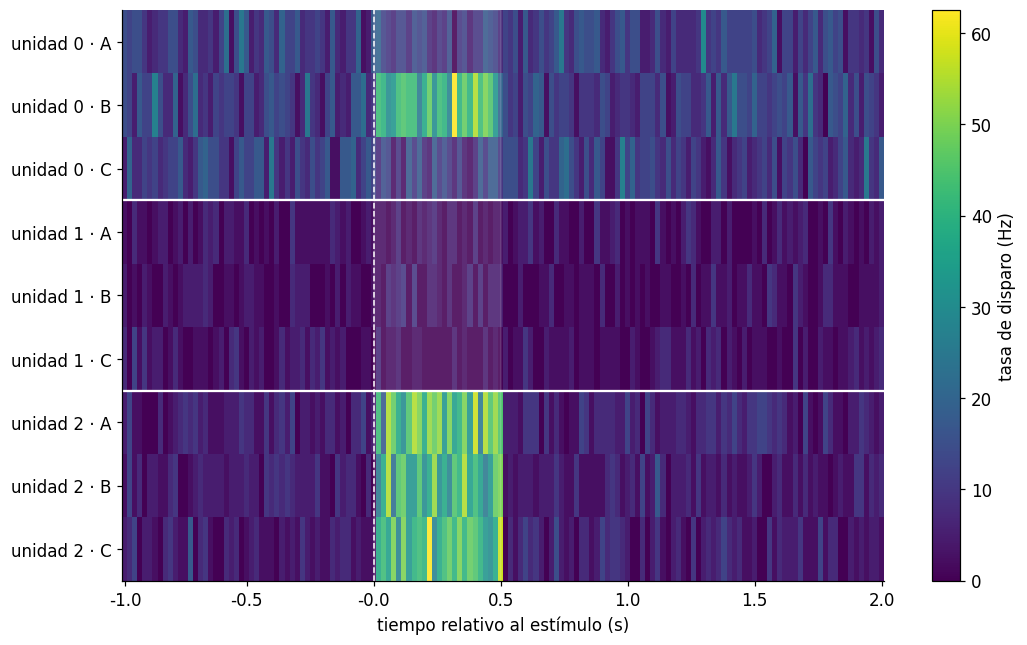

In [45]:
# Su código aquí.
ancho_bin = 0.02   # el mismo elegido en M

filas, etiquetas_fila = [], []
for u in np.unique(etiquetas):
    for cond in condicion_color:
        ensayos_cond = [alineados[u][i] for i in range(len(inicios)) if condiciones[i] == cond]
        centros, tasa = psth(ensayos_cond, (-1.0, 2.0), ancho_bin)
        filas.append(tasa)
        etiquetas_fila.append(f"unidad {u} · {cond}")

matriz = np.array(filas)   # (9, n_bins)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(matriz, aspect="auto", cmap="viridis", vmin=0, vmax=matriz.max())

# eje x en segundos, no en índice de bin
pos_ticks = np.linspace(0, len(centros) - 1, 7).astype(int)
ax.set_xticks(pos_ticks)
ax.set_xticklabels([f"{centros[p]:.1f}" for p in pos_ticks])
ax.set_xlabel("tiempo relativo al estímulo (s)")

col_t0   = np.argmin(np.abs(centros - 0))
col_test = np.argmin(np.abs(centros - t_est))
ax.axvline(col_t0, color="white", lw=1, ls="--")
ax.axvspan(col_t0, col_test, color="white", alpha=0.12, zorder=2)

ax.set_yticks(np.arange(len(etiquetas_fila)))
ax.set_yticklabels(etiquetas_fila)
for i in [2.5, 5.5]:                              # separa cada unidad (bloques de 3 filas)
    ax.axhline(i, color="white", lw=1.5)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("tasa de disparo (Hz)")
plt.tight_layout()

**Lo que el heatmap muestra y el PSTH escondía:** el heatmap ayuda a entender que no todas la neuronas responden de la misma manera a un estimulo, ya que algunas tienen una respuesta fuerte y que es temporalmente localizada, que son especialmente 0-B Y 2-A. esto debido a que las demas responden de una amnera debil o que no responden directamente. por ulyimo nos permite distinguir las diferencias en el inicio, duracion e intensidad que puede ser confuso al momento de solo ver numeros.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

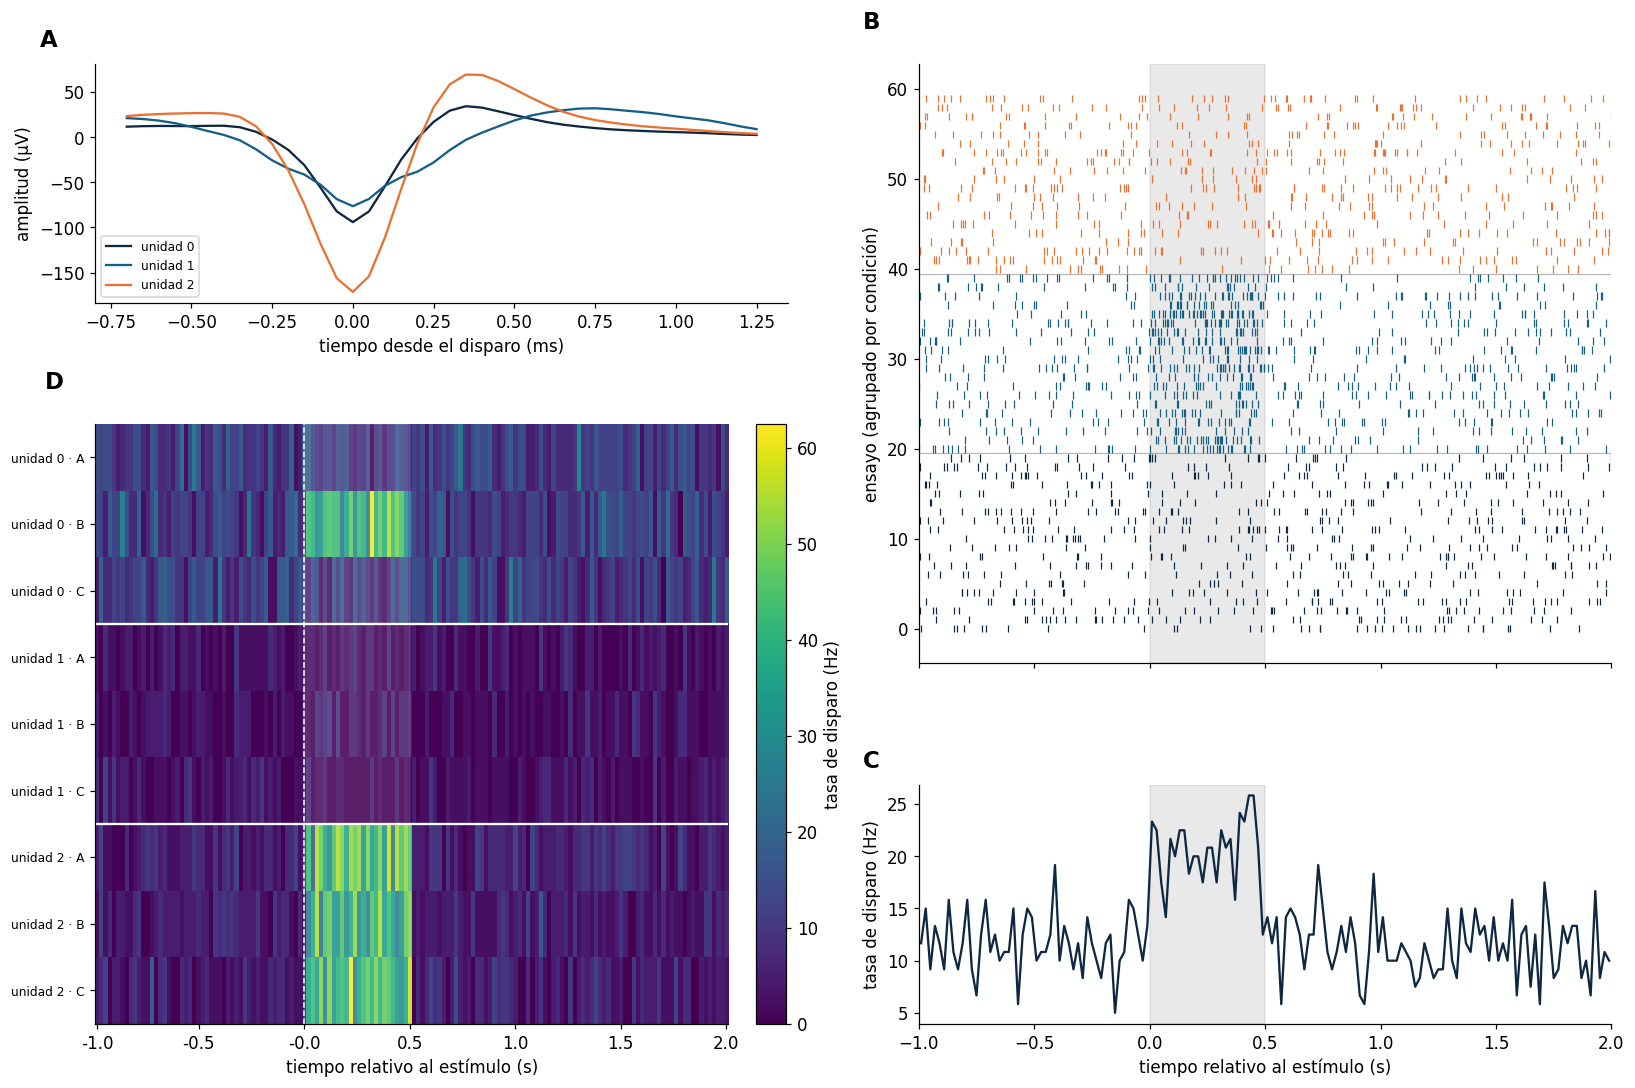

In [46]:
# @title
# Su código aquí.
import os
os.makedirs("figuras", exist_ok=True)

fig, axd = plt.subplot_mosaic(
    [["A", "B"],
     ["D", "B"],
     ["D", "C"]],
    figsize=(15, 10),
)

def etiquetar_panel(ax, letra):
    ax.text(-0.08, 1.05, letra, transform=ax.transAxes, fontsize=15, fontweight="bold", va="bottom")

# --- A: formas promedio, misma escala ---
t_forma_ms = (np.arange(formas.shape[1]) - pre) / fs * 1000
for u, color in zip(np.unique(etiquetas), [NAVY, TEAL, ORANGE]):
    promedio = formas[etiquetas == u].mean(axis=0)
    axd["A"].plot(t_forma_ms, promedio, color=color, label=f"unidad {u}")
axd["A"].set_xlabel("tiempo desde el disparo (ms)")
axd["A"].set_ylabel("amplitud (µV)")
axd["A"].legend(fontsize=8)
etiquetar_panel(axd["A"], "A")

# --- B: raster de la unidad que responde ---
orden = np.argsort(condiciones, kind="stable")
filas_r   = [alineados[unidad_que_responde][i] for i in orden]
colores_r = [condicion_color[condiciones[i]] for i in orden]
axd["B"].eventplot(filas_r, colors=colores_r, linelengths=0.8, linewidths=0.8)
axd["B"].axvspan(0, t_est, color=GRAY, alpha=0.15, zorder=0)
cond_ordenadas = condiciones[orden]
for c in np.where(cond_ordenadas[:-1] != cond_ordenadas[1:])[0] + 0.5:
    axd["B"].axhline(c, color=GRAY, lw=0.8, alpha=0.5)
axd["B"].set_ylabel("ensayo (agrupado por condición)")
axd["B"].set_xlim(-1.0, 2.0)
etiquetar_panel(axd["B"], "B")

# --- C: PSTH de la misma unidad, mismo eje x que B ---
centros_psth, tasa = psth(alineados[unidad_que_responde], (-1.0, 2.0), ancho_bin)
axd["C"].plot(centros_psth, tasa, color=NAVY)
axd["C"].axvspan(0, t_est, color=GRAY, alpha=0.15, zorder=0)
axd["C"].set_xlabel("tiempo relativo al estímulo (s)")
axd["C"].set_ylabel("tasa de disparo (Hz)")
etiquetar_panel(axd["C"], "C")

axd["C"].sharex(axd["B"])
plt.setp(axd["B"].get_xticklabels(), visible=False)   # evita ticks duplicados entre B y C

# --- D: heatmap multiunidad (reusa matriz/centros de la sección N) ---
im = axd["D"].imshow(matriz, aspect="auto", cmap="viridis", vmin=0, vmax=matriz.max())
pos_ticks = np.linspace(0, len(centros) - 1, 7).astype(int)
axd["D"].set_xticks(pos_ticks)
axd["D"].set_xticklabels([f"{centros[p]:.1f}" for p in pos_ticks])
axd["D"].set_xlabel("tiempo relativo al estímulo (s)")
axd["D"].axvline(col_t0, color="white", lw=1, ls="--")
axd["D"].axvspan(col_t0, col_test, color="white", alpha=0.12, zorder=2)
axd["D"].set_yticks(np.arange(len(etiquetas_fila)))
axd["D"].set_yticklabels(etiquetas_fila, fontsize=8)
for i in [2.5, 5.5]:
    axd["D"].axhline(i, color="white", lw=1.5)
cbar = fig.colorbar(im, ax=axd["D"], fraction=0.046, pad=0.04)
cbar.set_label("tasa de disparo (Hz)")
etiquetar_panel(axd["D"], "D")

plt.tight_layout()
plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")
plt.show()

**Pregunta P2.** El pie de la figura:

Figura 1. Resumen de la actividad neuronal registrada durante la presentación de los estímulos. (A) Formas de onda promedio de las tres unidades identificadas. (B) Raster de la unidad 0 agrupado por condición, mostrando la distribución temporal de los disparos. (C) PSTH de la unidad 0, expresado como tasa de disparo (Hz), con el periodo de estímulo sombreado. (D) Heatmap de la tasa de disparo de las tres unidades bajo las diferentes condiciones y a lo largo del tiempo relativo al estímulo.

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**
En el registro de las tres unidades de diferentes estimulos, se mostro que la unidad 0 tuvo una respuesta especialmente clara a la condición B, puesto que alcanzó al rededor de 60Hz en la duración del estimulo. Por su parte la unidad 1 no presento una respuesta clara temporalmente en ninguna de las condiciones y permanecio en el rango de actividad basal, es decir al rededor de 10Hz. Finalmente la unidad 2 tuvo respuestas bien marcadas en las tres condiciones, con tasas que rondaron los 50-60Hz. Estas diferencias se evidencian de forma clara en la figura final sección D (figura del punto O) del heatmap. La separación de unidades tuvo un acierto global de 94.9% y pese a que las unidades 0 y 2 contienen la mayor parte de los errores de clasificación; la detección de spikes tuvo una precision de 0.999 y una exhaustividad de 0.970, las violaciones del refractario fueron de 0.00% en las unidades 0 y 1, y de 0.09% en la unidad 2, por lo que se puede decir que la separación es aparentemente limpia.
Sin embargo, no se puede asegurar en este analisis que las respuestas obtenidas para la unidad 2 son especificas a las tres condiciones, por lo cual es necesario comparar la tasa de disparo con la linea basal de cada condicion estadisticamente, y realizar replicas.

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:**
> Crea una función llamada filtrar() para filtrar una señal. La función debe recibir como entradas x (señal), fs (frecuencia de muestreo), baja=None (frecuencia de corte inferior), alta=None (frecuencia de corte superior) y orden=3. Debe devolver la señal filtrada, manteniendo el mismo tamaño que x.

Usa un filtro Butterworth. Si solamente se proporciona alta, debe funcionar como un filtro pasa-bajos. Si solamente se proporciona baja, debe funcionar como un filtro pasa-altos. Si se proporcionan baja y alta, debe funcionar como un filtro pasa-banda.

El filtrado debe realizarse con fase cero utilizando filtfilt o sosfiltfilt, para evitar desplazar temporalmente la señal. Las frecuencias de corte deben normalizarse respecto a la frecuencia de Nyquist.

**Respuesta del modelo:**
> La IA generó una función que utilizaba sosfiltfilt() para aplicar el filtro Butterworth.

**Qué estaba mal:**
> se obtuvo un error: NameError: name 'sosfiltfilt' is not defined

**Cómo lo corregimos:**
>Como ya estábamos trabajando con filtfilt, decidimos usar esa función o importar correctamente sosfiltfilt
---

### Intercambio 2

**Prompt:**
>Trabajo en Python con numpy y scipy. Tengo un array cruda con el voltaje (en µV) de un registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en 60 Hz y su armónico en 120 Hz. Escríbeme una función notch(x, f0, fs, Q=30) que use scipy.signal.iirnotch para diseñar el filtro y scipy.signal.filtfilt para aplicarlo. Explícame qué controla el parámetro Q y por qué en electrofisiología se usa filtfilt y no lfilter. Rotula todo con unidades y explícame cada línea.

**Respuesta del modelo:**
> La IA propuso una función notch() que diseña un filtro notch con iirnotch y lo aplica con filtfilt, usando la frecuencia de muestreo fs.

**Qué estaba mal:**
>El código por sí mismo no garantizaba que el resto del procesamiento estuviera correctamente planteado. En particular, había que tener cuidado con qué frecuencia se quería eliminar y en qué etapa del análisis. El ejercicio pedía quitar 60 y 120 Hz para obtener el LFP, pero también había que considerar que un notch demasiado amplio podía eliminar señal que buscabamso.

**Cómo lo corregimos:**

---

### Intercambio 3

**Prompt:**
>Se necesita una funcion que mire la forma de cada disparo: Para cada disparo detectado,  se debe extraer una ventana de la señal filtrada que vaya de 0,7 ms antes a 1,3 ms después del instante del mínimo detectado. El resultado será una matriz de n_disparos × n_muestras_de_la_ventana. Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana se sale del array. Después debe graficar 200 formas superpuestas con transparencia (alpha=0.1) y encima la forma promedio. El eje x en milisegundos relativos al mínimo, no en número de muestra. Al final debe quedar definida la matriz formas.

**Respuesta del modelo:**
>La IA generó un bloque que convertía 0,7 y 1,3 ms a número de muestras utilizando fs, recorría los índices detectados, descartaba los eventos cuya ventana se salía del registro y almacenaba las formas en una matriz formas. También propuso el código para graficar las primeras 200 formas y su promedio.

**Qué estaba mal:**
>Había que tener especial cuidado con los eventos de los bordes. No bastaba con descartar solamente la forma: también había que eliminar el índice y el tiempo correspondiente para que formas, indices y tiempos siguieran alineados. Además, el eje x no podía ser simplemente el número de muestra. El ejercicio pedía tiempo relativo al mínimo y expresado en milisegundos

**Cómo lo corregimos:**
> Se añadió una comprobación antes de extraer cada ventana, y se guardaron simultáneamente los índices y tiempos válidos,

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [47]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()

5461 disparos guardados en spikes_taller1.csv
unidad
0    2685
1     599
2    2177
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,2
1,0.15945,0
2,0.17240,0
3,0.28330,2
4,0.30670,0
